In [ ]:
#PR9: PRINCIPAL COMPONENT ANALYSIS(PCA)

In [1]:
from ucimlrepo import fetch_ucirepo 
import pandas as pd
import numpy as np

optical_recognition_of_handwritten_digits = fetch_ucirepo(id=80) 
x = optical_recognition_of_handwritten_digits.data.features 
y = optical_recognition_of_handwritten_digits.data.targets 
  
data = pd.concat([x, y], axis=1)

In [2]:
print("No. of rows and cols:", data.shape)
print("\nColumns:", data.columns)

No. of rows and cols: (5620, 65)

Columns: Index(['Attribute1', 'Attribute2', 'Attribute3', 'Attribute4', 'Attribute5',
       'Attribute6', 'Attribute7', 'Attribute8', 'Attribute9', 'Attribute10',
       'Attribute11', 'Attribute12', 'Attribute13', 'Attribute14',
       'Attribute15', 'Attribute16', 'Attribute17', 'Attribute18',
       'Attribute19', 'Attribute20', 'Attribute21', 'Attribute22',
       'Attribute23', 'Attribute24', 'Attribute25', 'Attribute26',
       'Attribute27', 'Attribute28', 'Attribute29', 'Attribute30',
       'Attribute31', 'Attribute32', 'Attribute33', 'Attribute34',
       'Attribute35', 'Attribute36', 'Attribute37', 'Attribute38',
       'Attribute39', 'Attribute40', 'Attribute41', 'Attribute42',
       'Attribute43', 'Attribute44', 'Attribute45', 'Attribute46',
       'Attribute47', 'Attribute48', 'Attribute49', 'Attribute50',
       'Attribute51', 'Attribute52', 'Attribute53', 'Attribute54',
       'Attribute55', 'Attribute56', 'Attribute57', 'Attribute58'

In [3]:
data.head()

,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,...,Attribute56,Attribute57,Attribute58,Attribute59,Attribute60,Attribute61,Attribute62,Attribute63,Attribute64,class
0,0,1,6,15,12,1,0,0,0,7,...,0,0,0,6,14,7,1,0,0,0
1,0,0,10,16,6,0,0,0,0,7,...,0,0,0,10,16,15,3,0,0,0
2,0,0,8,15,16,13,0,0,0,1,...,0,0,0,9,14,0,0,0,0,7
3,0,0,0,3,11,16,0,0,0,0,...,0,0,0,0,1,15,2,0,0,4
4,0,0,5,14,4,0,0,0,0,0,...,0,0,0,4,12,14,7,0,0,6


In [4]:
data.tail()

,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,...,Attribute56,Attribute57,Attribute58,Attribute59,Attribute60,Attribute61,Attribute62,Attribute63,Attribute64,class
5615,0,0,4,10,13,6,0,0,0,1,...,0,0,0,2,14,15,9,0,0,9
5616,0,0,6,16,13,11,1,0,0,0,...,0,0,0,6,16,14,6,0,0,0
5617,0,0,1,11,15,1,0,0,0,0,...,0,0,0,2,9,13,6,0,0,8
5618,0,0,2,10,7,0,0,0,0,0,...,0,0,0,5,12,16,12,0,0,9
5619,0,0,10,14,8,1,0,0,0,2,...,0,0,1,8,12,14,12,1,0,8


In [5]:
data.dtypes

Attribute1     int64
Attribute2     int64
Attribute3     int64
Attribute4     int64
Attribute5     int64
               ...  
Attribute61    int64
Attribute62    int64
Attribute63    int64
Attribute64    int64
class          int64
Length: 65, dtype: object

In [6]:
data.describe()

,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,...,Attribute56,Attribute57,Attribute58,Attribute59,Attribute60,Attribute61,Attribute62,Attribute63,Attribute64,class
count,5620.0,5620.000000,5620.000000,5620.000000,5620.000000,5620.000000,5620.000000,5620.000000,5620.000000,5620.000000,...,5620.000000,5620.000000,5620.000000,5620.000000,5620.000000,5620.000000,5620.000000,5620.000000,5620.000000,5620.000000
mean,0.0,0.302135,5.393238,11.815480,11.578292,5.593772,1.379359,0.138256,0.003203,1.971174,...,0.166904,0.000356,0.281851,5.760498,11.989680,11.572420,6.720819,2.093594,0.254093,4.495196
std,0.0,0.879962,4.672719,4.255952,4.462546,5.631149,3.356633,1.046998,0.090423,3.098815,...,0.843455,0.018863,0.929969,5.021145,4.347542,4.975675,5.815564,4.047959,1.418558,2.868131
min,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.0,0.000000,1.000000,10.000000,9.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,10.000000,9.000000,0.000000,0.000000,0.000000,2.000000
50%,0.0,0.000000,5.000000,13.000000,13.000000,4.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,5.000000,13.000000,13.000000,6.000000,0.000000,0.000000,4.000000
75%,0.0,0.000000,9.000000,15.000000,15.000000,10.000000,0.000000,0.000000,0.000000,3.000000,...,0.000000,0.000000,0.000000,10.000000,15.000000,16.000000,12.000000,2.000000,0.000000,7.000000
max,0.0,8.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,5.000000,16.000000,...,13.000000,1.000000,10.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,9.000000


In [7]:
data.isnull().sum()

Attribute1     0
Attribute2     0
Attribute3     0
Attribute4     0
Attribute5     0
              ..
Attribute61    0
Attribute62    0
Attribute63    0
Attribute64    0
class          0
Length: 65, dtype: int64

In [8]:
from sklearn.preprocessing import StandardScaler

x = data.drop('class', axis=1)  
y = data['class']               

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [9]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(x_scaled)

PCA()

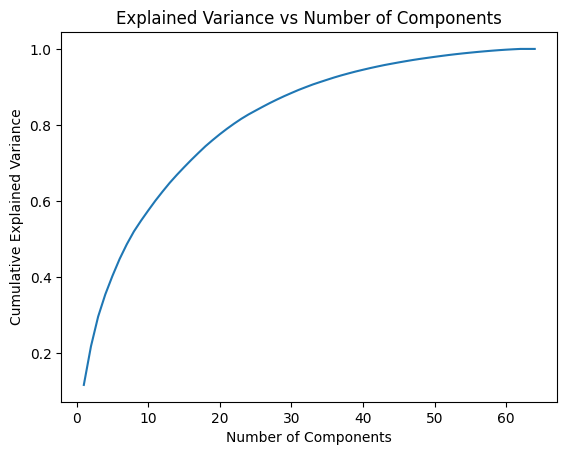

In [10]:
import matplotlib.pyplot as plt

explained_variance = pca.explained_variance_ratio_.cumsum()
plt.plot(range(1, len(explained_variance) + 1), explained_variance)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs Number of Components')
plt.show()

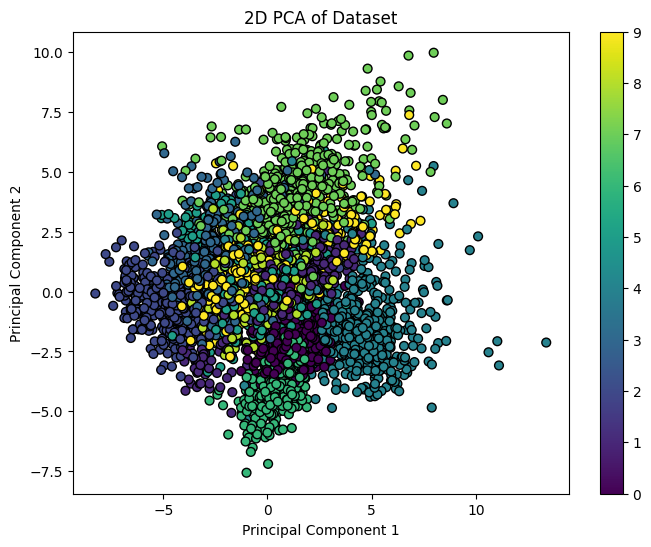

In [11]:
#2D VISUALIZATION
pca_2d = PCA(n_components=2)
x_reduced_2d = pca_2d.fit_transform(x_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(x_reduced_2d[:, 0], x_reduced_2d[:, 1], c=y, cmap='viridis', edgecolor='k', s=40)
plt.colorbar()
plt.title('2D PCA of Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

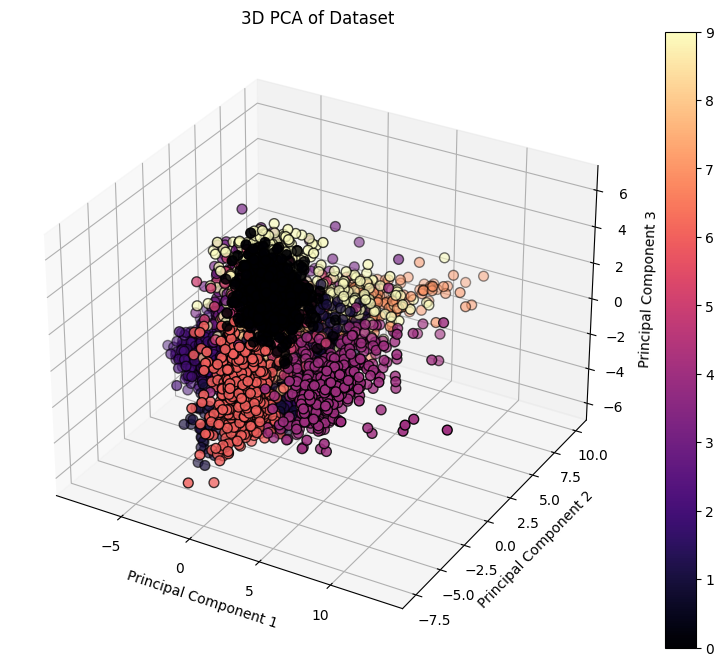

In [12]:
#3D VISUALIZATION
from mpl_toolkits.mplot3d import Axes3D

pca_3d = PCA(n_components=3)
x_reduced_3d = pca_3d.fit_transform(x_scaled)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(x_reduced_3d[:, 0], x_reduced_3d[:, 1], x_reduced_3d[:, 2], c=y, cmap='magma', edgecolor='k', s=50)
plt.colorbar(sc)
ax.set_title('3D PCA of Dataset')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
plt.show()

In [13]:
#Explained variance ratio for each principal component
explained_variance_ratio = pca.explained_variance_ratio_

#Cumulative explained variance
cumulative_variance = explained_variance_ratio.cumsum()

for i, (var, cum_var) in enumerate(zip(explained_variance_ratio, cumulative_variance), 1):
    print(f"Principal Component {i}: {var:.4f} variance explained, Cumulative: {cum_var:.4f}")

Principal Component 1: 0.1161 variance explained, Cumulative: 0.1161
Principal Component 2: 0.1017 variance explained, Cumulative: 0.2178
Principal Component 3: 0.0780 variance explained, Cumulative: 0.2958
Principal Component 4: 0.0584 variance explained, Cumulative: 0.3542
Principal Component 5: 0.0487 variance explained, Cumulative: 0.4029
Principal Component 6: 0.0444 variance explained, Cumulative: 0.4473
Principal Component 7: 0.0386 variance explained, Cumulative: 0.4859
Principal Component 8: 0.0340 variance explained, Cumulative: 0.5199
Principal Component 9: 0.0285 variance explained, Cumulative: 0.5484
Principal Component 10: 0.0266 variance explained, Cumulative: 0.5750
Principal Component 11: 0.0258 variance explained, Cumulative: 0.6008
Principal Component 12: 0.0240 variance explained, Cumulative: 0.6248
Principal Component 13: 0.0230 variance explained, Cumulative: 0.6477
Principal Component 14: 0.0210 variance explained, Cumulative: 0.6687
Principal Component 15: 0.019